### Potencia las Ventas con IA: Clustering, Predicción, sistemas de recomendaciones y AI generativa para construir un asistente de venta de consumo mayorista.

<p align="center">Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones.</p>
<p align="center">Facultad de Matemática, Astronomía, Física y Computación (UNC).</p>


#### Integrantes

- María Guadalupe Serra

- Dámaso José Solinas

- María Emilia Briggiler

- Iván Gabriel Bainotti


---

Este proyecto se basa en un conjunto de datos transaccionales que registra ventas de productos alimenticios en el canal mayorista, realizadas a distintos puntos de venta (PDV) que operan como clientes del sistema. El propósito es aplicar técnicas de ciencia de datos para identificar patrones comerciales, optimizar decisiones estratégicas y generar valor a partir del análisis del comportamiento de compra.

### Práctico 2 – Análisis Exploratorio y Curación de Datos

#### 📚 Índice

1. [Carga del dataset](#1-carga-del-dataset)
2. [Depuración de Datos](#2-depuración-de-datos)
   - [Duplicados](#duplicados)
   - [Valores faltantes](#valores-faltantes)
   - [Outliers](#outliers)
3. [Agrupación del dataset por granularidad](#3-agrupación-del-dataset-por-granularidad)
   - [Análisis de granularidad](#análisis-de-granularidad)
   - [Filtrado de series](#filtrado-de-series)
   - [Completado de las series](#completado-de-las-series)
4. [Deflactación de montos](#4-deflactación-de-montos)
5. [Transformación de variables](#5-transformación-de-variables)
6. [Estandarización o normalización](#6-estandarización-o-normalización)
7. [Verificación de consistencia](#7-verificación-de-consistencia)

#### Librerías

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
sns.set_theme()

### 1. Carga del dataset


In [3]:
url = "https://raw.githubusercontent.com/Mentoria-M11-g1/practico_1_eda/main/data/sales_data.parquet"
df = pd.read_parquet(url)

In [4]:
# Columnas relacionadas al precio y cantidad
COLUMNS_TO_SCALE = [
    'canti',
    'precio_uni',
    'boni_porcen',
    'boni_impor',
    'iva1_impor', 
    'iva_percep_porcen', 
    'iva_percep_impor', 
    'impor_grava',
    'conver', 
    'canti_venta', 
    'boni_impor_ori', 
    'iva_percep_impor_ori',
    'boni_porcen_precio', 
    'boni_impor_precio', 
    'precio_uni_neto',
    'precio_total'
]

df[COLUMNS_TO_SCALE] = df[COLUMNS_TO_SCALE] / 1_000_000

- Se eliminaron columnas redundantes detectadas en el EDA.

- Como `orden_compra_nume`, `pedi_nume` y `factu_nume` hacen referencia a la venta y coinciden en más del 90 % de los registros, se conserva solo factu_nume, dado que la granularidad es por factura.

- También se mantiene únicamente `fecha` como referencia temporal.

In [5]:
COLUMNS_TO_DROP = [
    'factu_codi',       # Código de factura, no relevante
    'usua',             # Desconocido, 89% de valores es 34 y 11% es 24
    'pedi_codi',        # Código de pedido: pedi, pedim, pedie, no relevante
    'factu_letra',      # Letra de la factura, no relevante
    'iva_cate',         # categoría del IVA, no relevante
    'iva_percep',       # IVA desconocido, 95% de valores son 0.0
    'impre_marca',      # Desconocido, 92% de valores es 1, 7% es 2
    'conver_alter',     # Conversión alternativa, no relevante
    'host_name_alta',   # Parece info relativa al sistema, no relevante
    'estado_talon',     # Estado del talonario, no relevante
    'origen_pedido',    # codificación del origen del pedido, 89% de valores es a.
    'linea_nume',       # Identificador del dispositivo con el que se registro la venta

    'orden_compra_nume', # Orden de compra, redundante con factu_nume
    'pedi_nume',         # Número de pedido, redundante con factu_nume
    'fecha_alta',        # Fecha de alta, redundante con fecha
    'fecha_regis',       # Fecha de registro, redundante con fecha
]

filtered_df = df.drop(columns=COLUMNS_TO_DROP)
filtered_df.shape

(310217, 36)

### 2. Depuración de Datos



🎯 **Objetivos**:
- Tratar valores duplicados y faltantes detectados en el EDA.
- Analizar outliers y productos sin ventas significativas.


Dado que al agrupar el dataset por unidad de tiempo se pierde granularidad, los outliers se analizan previamente al agregado temporal.

#### Duplicados

In [6]:
# Cantidad de filas duplicadas en el DataFrame
duplicates_count = filtered_df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicates_count}")
print(f"Porcentaje de filas duplicadas: {duplicates_count / len(filtered_df) * 100:.2f}%")

Cantidad de filas duplicadas: 6097
Porcentaje de filas duplicadas: 1.97%


- Si bien hay filas duplicadas, el porcentaje es menor al 2%. Dado que no se puede determinar si se trata de registros cargados dos veces o de ítems de facturas idénticos (lo cual podría ocurrir, por ejemplo, para aprovechar promociones), se opta por no eliminarlas.

#### Valores faltantes

In [7]:
def missing_values_summary(df):
    """
    Retorna un DataFrame con el resumen de valores faltantes en cada columna.
    """
    nulls = pd.DataFrame({
        'valores_faltantes': df.isnull().sum(),
        'valores_faltantes (%)': df.isnull().mean() * 100,
    }).reset_index().rename(columns={'index': 'columna'}).sort_values('valores_faltantes (%)', ascending=False)

    return nulls[nulls['valores_faltantes'] > 0]

In [8]:
missing_values_summary(filtered_df)

,columna,valores_faltantes,valores_faltantes (%)
16,depo,53587,17.274037
10,entre_lugar,151,0.048676
11,entre_fecha,151,0.048676
9,impor_gravado,151,0.048676
15,tipo_negocio,151,0.048676
14,vende,151,0.048676
8,pedi_sucur,151,0.048676


Del EDA se observó que:

- `depo` está vinculado al SKU.

- Las 151 filas con valores faltantes presentan el mismo error de carga en todas las columnas. Como representan solo el 0.049 % del total, se opta por eliminarlas.

In [9]:
# SKU con '999' en el medio
sku_999 = filtered_df[filtered_df['produc'].str.contains(r'^000-999-', na=False)]

# SKU únicos con '999'
all_999_skus = set(sku_999['produc'].unique())

# SKU con '999' y depo faltante
sku_999_missing_depo = set(sku_999[sku_999['depo'].isna()]['produc'].unique())

print(f"Total de SKUs con '999': {len(all_999_skus)}")
print(f"Con 'depo' faltante: {len(sku_999_missing_depo)}")
print(f"Porcentaje con 'depo' faltante: {len(sku_999_missing_depo) / len(all_999_skus) * 100:.2f}%")

Total de SKUs con '999': 6669
Con 'depo' faltante: 6657
Porcentaje con 'depo' faltante: 99.82%


- Los SKU con prefijo **000-999** corresponden al **depósito con valores faltantes**, por lo tanto asignamos el número **4** para identificarlo e imputar los valores ausentes.

In [10]:
def _impute_depo(df):
    """
    Imputa el valor de 'depo' para los SKUs que contienen '999' en su código.
    """
    new_depo_value = 4
    df.loc[df['produc'].str.contains(r'^000-999-', na=False), 'depo'] = new_depo_value
    return df

def impute_columns(df):
    """
    Imputa los valores faltantes en las columnas del DataFrame.
    """
    df = _impute_depo(df)
    return df

In [11]:
filtered_df = impute_columns(filtered_df)
filtered_df = filtered_df.dropna()

In [12]:
# Verificar si quedan valores nulos
missing_values_summary(filtered_df)

,columna,valores_faltantes,valores_faltantes (%)


#### Outliers

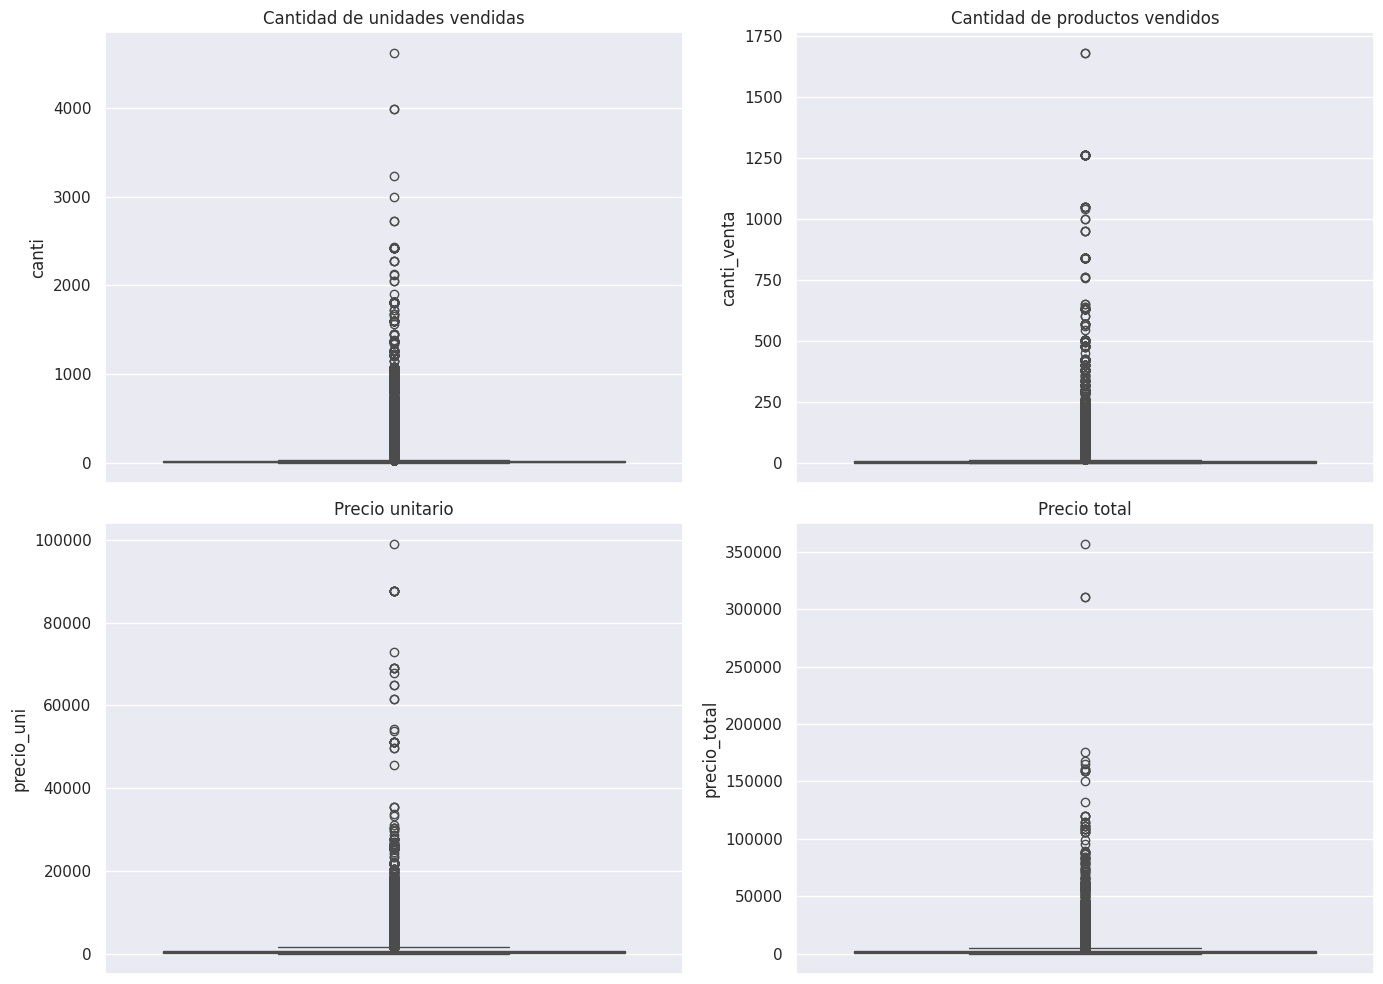

In [13]:
# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=filtered_df, y='canti', ax=axes[0, 0])
axes[0, 0].set_title('Cantidad de unidades vendidas')

sns.boxplot(data=filtered_df, y='canti_venta', ax=axes[0, 1])
axes[0, 1].set_title('Cantidad de productos vendidos')

sns.boxplot(data=filtered_df, y='precio_uni', ax=axes[1, 0])
axes[1, 0].set_title('Precio unitario')

sns.boxplot(data=filtered_df, y='precio_total', ax=axes[1, 1])
axes[1, 1].set_title('Precio total')

plt.tight_layout()
plt.show()

- Si bien las distribuciones son altamente asimétricas y presentan muchos valores elevados, estos podrían corresponderse con compras grandes. Además, no se observan valores claramente aislados del resto.

- En el caso de los valores monetarios, conviene analizarlos una vez deflactados, ya que actualmente predominan los precios de fechas más recientes.

Del EDA observamos que hay muchos SKUs con pocas ventas que no vale la pena considerar. Es conveniente filtrar algunos de estos productos para evitar generar series altamente incompletas o con ventas en un solo mes.

In [14]:
# Estadisticas sobre todo el rango temporal
skus_grouped = filtered_df.groupby('produc').agg({
    'canti': ['sum', 'std', 'min', 'max', 'median'],
    #'canti_venta': ['sum', 'std', 'min', 'max', 'median']
}).reset_index()

# Renombrar columnas
skus_grouped.columns = ['produc', 'canti_sum', 'canti_std', 'canti_min', 'canti_max', 'canti_median']
skus_grouped.sort_values(by='canti_sum', ascending=True).head(10)

,produc,canti_sum,canti_std,canti_min,canti_max,canti_median
7719,000-999-sasa2304b,1.0,NaN,1.0,1.0,1.0
7715,000-999-sasa2105a,1.0,NaN,1.0,1.0,1.0
7744,000-999-tkn1578,1.0,NaN,1.0,1.0,1.0
7685,000-999-cptgo1,1.0,NaN,1.0,1.0,1.0
7682,000-999-cptch1,1.0,NaN,1.0,1.0,1.0
7729,000-999-sasa2907ch,1.0,NaN,1.0,1.0,1.0
7728,000-999-sasa2708hel,1.0,NaN,1.0,1.0,1.0
7733,000-999-sasago1002,1.0,NaN,1.0,1.0,1.0
7731,000-999-sasach1002,1.0,NaN,1.0,1.0,1.0
7761,000-999-tsuharc2,1.0,NaN,1.0,1.0,1.0


In [15]:
skus_grouped['canti_sum'].describe()

count      7765.000000
mean        899.194205
std       10101.642292
min           1.000000
25%           3.000000
50%           8.000000
75%          25.000000
max      449566.000000
Name: canti_sum, dtype: float64

- La media y la mediana difieren enormemente; muchos SKUs tienen muy pocas ventas a lo largo de todo el rango del dataset y no vale la pena considerarlos.

- Se ordenaron los SKUs de mayor a menor según la cantidad total vendida, y se conservaron aquellos que acumulan el 95% del total de unidades vendidas.

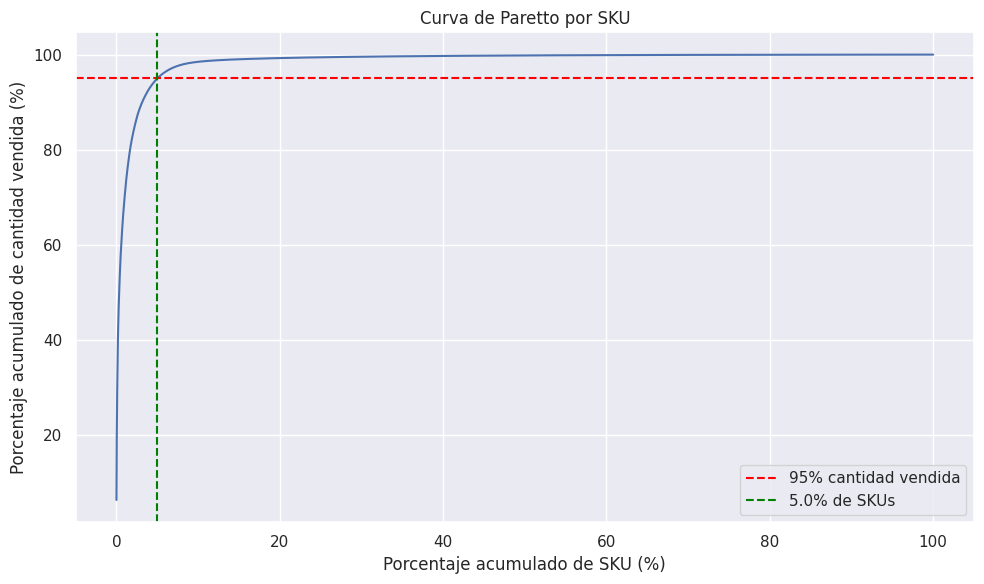

In [16]:
canti_pct_cum_limit = 95

ventas_totales = filtered_df.groupby('produc')['canti'].sum()
# Ordenar los SKUs por cantidad total vendida (de mayor a menor)
paretto_df = ventas_totales.sort_values(ascending=False).reset_index()
paretto_df.columns = ['produc', 'canti']

# Calcular el porcentaje acumulado de la cantidad vendida
paretto_df['pct_canti_acum'] = paretto_df['canti'].cumsum() / paretto_df['canti'].sum() * 100

# Calcular el porcentaje acumulado de la cantidad de SKU
paretto_df['pct_sku_acum'] = (paretto_df.index + 1) / len(paretto_df) * 100

# Encontrar el punto donde se alcanza el 95% de la cantidad
cutoff_index = paretto_df[paretto_df['pct_canti_acum'] >= canti_pct_cum_limit].index[0]
x_cut = paretto_df.loc[cutoff_index, 'pct_sku_acum']

# Graficar el Paretto
plt.figure(figsize=(10, 6))
plt.plot(paretto_df['pct_sku_acum'], paretto_df['pct_canti_acum'])

# Líneas de referencia
plt.axhline(y=canti_pct_cum_limit, color='red', linestyle='--', label=f'{canti_pct_cum_limit}% cantidad vendida')
plt.axvline(x=x_cut, color='green', linestyle='--', label=f'{x_cut:.1f}% de SKUs')

plt.xlabel('Porcentaje acumulado de SKU (%)')
plt.ylabel('Porcentaje acumulado de cantidad vendida (%)')
plt.title('Curva de Paretto por SKU')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Filtrar el DataFrame para quedarnos solo con los SKUs que conforman el 95% de la cantidad vendida
skus_pct = paretto_df.loc[:cutoff_index, 'produc']
filtered_df = filtered_df[filtered_df['produc'].isin(skus_pct)]
filtered_df.shape

(212941, 36)

In [18]:
canti_total_por_sku = filtered_df.groupby('produc')['canti'].sum().reset_index(name='canti')
canti_total_por_sku.describe()

,canti
count,390.000000
mean,17008.420513
std,41978.758619
min,1557.000000
25%,2808.750000
50%,5703.000000
75%,14235.000000
max,449566.000000


In [19]:
# Porcentaje de filtrado del DataFrame
print(f"Porcentaje de filas restantes: {(filtered_df.shape[0] / df.shape[0]) * 100:.2f}%")

Porcentaje de filas restantes: 68.64%


Descripciones 

- Algunas descripciones no están estandarizadas, dado que para agregar el dataset por PDV + SKU es necesario conservar una sola descripcion para cada SKU, primero estandarizamos descripciones (remover espacios extra, puntuación, etc).

- Para los SKUs con más de una descripción, se eligió su valor más frecuente (moda).

In [20]:
def clean_description(texto):
    if pd.isnull(texto):
        return ""

    texto = texto.lower()                    # minúsculas
    texto = re.sub(r'[^\w\s]', ' ', texto)   # quitar puntuación, conservar letras y números
    texto = re.sub(r'\s+', ' ', texto)       # un solo espacio
    texto = texto.strip()                    # eliminar espacios iniciales/finales
    return texto

In [21]:
def descrip_per_sku(filtered_df):
    """
    Retorna descripciones únicas por SKU.
    """
    multiple_descriptions = filtered_df.groupby('produc')['descrip'].nunique()
    multiple_descriptions = multiple_descriptions[multiple_descriptions > 1]
    return multiple_descriptions

In [22]:
def stand_description_by_mode(df, column='descrip'):
    """
    Estandariza las descripciones de productos tomando la más frecuente (moda).
    """
    df = df.copy()
    df[column] = df.groupby('produc')[column].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    return df

In [23]:
# Cantidad de descripciones únicas
print(f"Cantidad de descripciones únicas: {filtered_df['descrip'].nunique()}")

filtered_df.loc[:, 'descrip'] = filtered_df['descrip'].apply(clean_description)
print(f"Cantidad de descripciones únicas después de la limpieza: {filtered_df['descrip'].nunique()}")

Cantidad de descripciones únicas: 403
Cantidad de descripciones únicas después de la limpieza: 401


In [24]:
# SKU con más de una descripción
print(f"Total SKUs con múltiples descripciones: {len(descrip_per_sku(filtered_df))}")

Total SKUs con múltiples descripciones: 14


In [25]:
filtered_df = stand_description_by_mode(filtered_df, column='descrip')
print(f"Total SKUs con múltiples descripciones: {len(descrip_per_sku(filtered_df))}")

Total SKUs con múltiples descripciones: 0


### 3. Agrupación del dataset por granularidad

🎯 **Objetivos**:
1. Definir granularidad temporal para agrupar las series.

2. Agrupar las series por cliente + SKU + periodo de tiempo elegido.
3. Analizar estadísticas generales de las series y definir criterios para filtrar aquellas aptas para predicción.
4. Imputar los períodos de tiempo faltantes en las series.

📌 **Consideraciones generales:**

1. Las series comienzan en la primera compra registrada y finalizan en la última fecha del dataset.

2. La longitud de una serie se define como la cantidad de períodos entre esas dos fechas.
3. La completitud se calcula como la proporción de períodos con ventas sobre el total de períodos dentro del rango de la serie.

In [26]:
def aggregate_by_pdv_sku(df, freq='M'):
    """
    Agregar el DataFrame a nivel de PDV (cliente) + SKU (produc) + periodo.
    """
    df = df.copy()
    df['fecha'] = pd.to_datetime(df['fecha'])
    df['period'] = df['fecha'].dt.to_period(freq)

    agg_df = (
        df.groupby(['cliente', 'produc', 'period'])
        .agg( # Por cliente, producto y periodo
              # Totales por periodo           
              cantidad_facturas=('factu_nume', 'nunique'),          # Número de facturas
              cantidad_unidades=('canti', 'sum'),                   # Cantidad de unidades vendidas
              cantidad_productos=('canti_venta', 'sum'),            # Cantidad de productos vendidos
              total_facturado=('precio_total', 'sum'),              # Total facturado

              # Promedios por periodo
              unidades_promedio_por_compra=('canti', 'mean'),        # Promedio de unidades por compra
              productos_promedio_por_compra=('canti_venta', 'mean'), # Promedio de productos por compra

              # Para los SKU
              precio_uni=('precio_uni', 'mean'),                     # Precio unitario promedio en el periodo
              descripcion=('descrip', 'first'), 
              depo=('depo', 'first'),

              # Agregar mas columnas si es necesario.
              # Tener en cuenta que muchas de las columnas
              # cambian por linea de factura (o por factura)
              # y sólo se conserva una por mes.
          )
          .reset_index()
    )
    return agg_df

Para analizar comportamientos generales de las series, se puede generar un dataset agregado considerando todos los períodos. Esto permite conocer distribuciones sobre:

- Porcentajes de ventas que representa cada serie respecto al total.

- Largo de las series y su porcentaje de períodos faltantes.

- Tiempo desde la última venta, útil para analizar cuánto tardan los clientes en volver a comprar un producto y desde cuándo una serie podría considerarse inactiva.


Dado que estas features se calculan sobre todos los períodos, **no deben utilizarse para predecir en series temporales**. Se identifican con el prefijo `s_`.

In [27]:
def series_summary_features(agg_df, col_ventas='cantidad_unidades'):
    """
    Agregar las series cliente + SKU sobre todos los periodos.

    Parámetros:
    - agg_df: DataFrame agregado por cliente, producto y periodo.
    - col_ventas: nombre de la columna de ventas.

    Devuelve:
    - DataFrame resumen con una fila por serie cliente + SKU.
    """
    df = agg_df.copy()
    id_cols = ['cliente', 'produc']

    # Periodo máximo global para calcular longitud esperada
    periodo_max_global = df['period'].max()
    ventas_totales_globales = df[col_ventas].sum()

    # Calcular features por serie
    resumen = (
        df.groupby(id_cols)
        .agg(
            s_primera_venta=('period', 'min'),
            s_ultima_venta=('period', 'max'),
            s_ventas_totales=(col_ventas, 'sum'),
            s_cantidad_total_facturas=('cantidad_facturas', 'sum'),
            s_cantidad_periodos_con_venta=('period', 'count')
        )
        .reset_index()
    )

    # Calcular features adicionales
    resumen['s_longitud_serie'] = (periodo_max_global - resumen['s_primera_venta']).apply(lambda x: x.n + 1)
    resumen['s_periodos_desde_ultima_venta'] = (periodo_max_global - resumen['s_ultima_venta']).apply(lambda x: x.n)
    resumen['s_completitud'] = resumen['s_cantidad_periodos_con_venta'] / resumen['s_longitud_serie']
    resumen['s_porcentaje_sobre_total_ventas'] = 100 * resumen['s_ventas_totales'] / ventas_totales_globales

    # Calcular período promedio entre ventas
    periodo_prom = (
        df
        .sort_values(id_cols + ['period'])
        .groupby(id_cols)['period']
        .apply(lambda x: x.diff().dropna().apply(lambda y: y.n).mean())
        .reset_index(name='s_periodo_prom_entre_ventas')
    )

    resumen = resumen.merge(periodo_prom, on=id_cols, how='left')

    return resumen

In [28]:
# Dataframe agregado por cliente + SKU + periodo
agg_df = aggregate_by_pdv_sku(filtered_df, freq='M')

agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166043 entries, 0 to 166042
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype    
---  ------                         --------------   -----    
 0   cliente                        166043 non-null  int64    
 1   produc                         166043 non-null  object   
 2   period                         166043 non-null  period[M]
 3   cantidad_facturas              166043 non-null  int64    
 4   cantidad_unidades              166043 non-null  float64  
 5   cantidad_productos             166043 non-null  float64  
 6   total_facturado                166043 non-null  float64  
 7   unidades_promedio_por_compra   166043 non-null  float64  
 8   productos_promedio_por_compra  166043 non-null  float64  
 9   precio_uni                     166043 non-null  float64  
 10  descripcion                    166043 non-null  object   
 11  depo                           166043 non-null  float64  
dtypes:

In [29]:
# Dataset agregado por serie (sobre todos los periodos)
summary_df = series_summary_features(agg_df, col_ventas='cantidad_unidades')

summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36784 entries, 0 to 36783
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype    
---  ------                           --------------  -----    
 0   cliente                          36784 non-null  int64    
 1   produc                           36784 non-null  object   
 2   s_primera_venta                  36784 non-null  period[M]
 3   s_ultima_venta                   36784 non-null  period[M]
 4   s_ventas_totales                 36784 non-null  float64  
 5   s_cantidad_total_facturas        36784 non-null  int64    
 6   s_cantidad_periodos_con_venta    36784 non-null  int64    
 7   s_longitud_serie                 36784 non-null  int64    
 8   s_periodos_desde_ultima_venta    36784 non-null  int64    
 9   s_completitud                    36784 non-null  float64  
 10  s_porcentaje_sobre_total_ventas  36784 non-null  float64  
 11  s_periodo_prom_entre_ventas      22876 non-null  objec

#### Análisis de granularidad

**Objetivos:**


- Evitar que haya demasiadas series incompletas.

- No agrupar en exceso los datos por período, ya que se pierde detalle de la serie.

- Para predecir el valor de una serie en un período, se requiere tener historial de la serie. Una agrupación mayor de los datos reduce la cantidad de períodos disponibles.

In [30]:
def evaluate_temporal_granularity(summary_df, freq='M'):
    """
    Evalúa la granularidad temporal
    
    Parámetros:
    - summary_df: DataFrame con una fila por serie y columnas como completitud, longitud, etc.
    - freq: granularidad temporal.
    
    Retorna:
    - DataFrame con métricas agregadas de calidad de la granularidad.
    """
    results = []
    
    # Porcentaje de periodos incompletos = 1 - completitud promedio
    pct_incomplete_periods = 100 * (1 - summary_df['s_completitud'].mean())

    # Porcentaje de series incompletas (completitud < 1)
    pct_series_incompletas = 100 * (summary_df['s_completitud'] < 1).mean()

    # Longitud promedio de las series
    avg_series_length = summary_df['s_longitud_serie'].mean()

    # Guardar resultados
    results.append({
        'granularidad': freq,
        'periodos_totales_distintos': summary_df['s_longitud_serie'].max(),
        'periodos_incompletos (%)': pct_incomplete_periods,
        'series_incompletas (%)': pct_series_incompletas,
        'longitud_promedio_series': avg_series_length
    })

    return pd.DataFrame(results)

In [31]:
frequencies = ['D', 'W', 'M', 'Q']
resultados = []

for freq in frequencies:
    agg_df_freq = aggregate_by_pdv_sku(filtered_df, freq=freq)
    summary_df_freq = series_summary_features(agg_df_freq, col_ventas='cantidad_unidades')

    # Calcular métricas de granularidad a partir del resumen
    eval_df = evaluate_temporal_granularity(summary_df_freq, freq=freq)
    
    # Guardar resultado
    resultados.append(eval_df)

# Concatenar todos los resultados en un único DataFrame
resultados_df = pd.concat(resultados, ignore_index=True)

resultados_df

,granularidad,periodos_totales_distintos,periodos_incompletos (%),series_incompletas (%),longitud_promedio_series
0,D,909,98.702232,99.986407,586.630655
1,W,130,91.810694,99.347542,84.280095
2,M,30,74.205476,96.696933,19.801109
3,Q,10,52.105895,83.944106,6.927006


- Las granularidades diaria y semanal presentan más del 90% de períodos incompletos. Al agrupar mensualmente, este porcentaje disminuye, aunque aún se mantiene elevado (74%).

- La granularidad trimestral reduce considerablemente los períodos incompletos, pero solo hay 10 períodos posibles (en 30 meses), y la longitud promedio de las series es de aproximadamente 7 trimestres, lo que limita el historial disponible para predicción.

- Se opta por la granularidad mensual, ya que ofrece un equilibrio razonable entre la cantidad de períodos incompletos y la longitud del historial disponible para predicción. Además, se alinea con los ritmos operativos habituales y resulta especialmente adecuada para la planificación y gestión de inventario. No obstante, será necesario filtrar aquellas series que presenten un alto porcentaje de valores faltantes.

#### Filtrado de series 

Consideramos tres criterios principales para filtrar las series (se pueden ajustar o agregar otros):

- **max_periodos_inactivos**: cantidad máxima de períodos sin ventas desde la última (detectar series descontinuadas o inactivas).

- **min_completitud**: porcentaje mínimo de períodos con ventas sobre los períodos totales.
- **min_longitud_serie**: longitud mínima de la serie.

**Objetivo**: filtrar series aptas para predicción, conservando la mayor cantidad total vendida posible.


In [32]:
def filter_series(summary_df, max_periodos_inactivos=4, min_completitud=0.7, min_longitud_serie=3):
    """
    Filtra las series según los criterios dados.
    
    Parámetros:
    - summary_df: DataFrame agregado por cliente y producto.
    - max_periodos_inactivos: máximo de periodos inactivos permitidos.
    - min_completitud: mínimo porcentaje de completitud requerido.
    - min_longitud_serie: mínimo número de periodos en la serie.
    
    Retorna:
    - DataFrame filtrado con las series que cumplen los criterios.
    """
    df = summary_df.copy()
    
    # Filtrar series
    filtered = df[
        (df['s_periodos_desde_ultima_venta'] <= max_periodos_inactivos) &
        (df['s_completitud'] >= min_completitud) &
        (df['s_longitud_serie'] >= min_longitud_serie)
    ]
    
    return filtered

**Longitud mínima de las series**

Series mas largas permiten:

- Tener un mayor historial para aprender patrones.

- Calcular features temporales (lags, rolling mean, etc.) de manera más confiable.

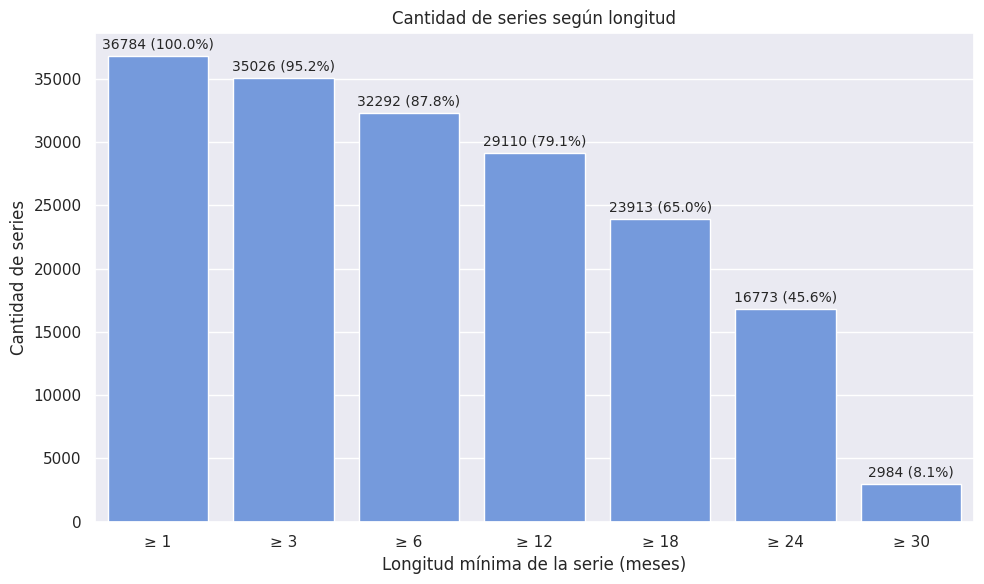

In [33]:
# Umbrales de longitud de serie
longitudes = [1, 3, 6, 12, 18, 24, 30]

# Calcular la cantidad de series con longitud de serie mayor o igual a cada umbral
series_por_longitud = [(summary_df['s_longitud_serie'] >= l).sum() for l in longitudes]
total_series = len(summary_df)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=longitudes, y=series_por_longitud, color='cornflowerblue')

# Actualizar los nombres de los ticks del eje x con "≥"
ticks_personalizados = [f"≥ {l}" for l in longitudes]
plt.xticks(ticks=range(len(longitudes)), labels=ticks_personalizados)

# Agregar etiquetas con número y porcentaje sobre cada barra
for i, y in enumerate(series_por_longitud):
    porcentaje = y / total_series * 100
    plt.text(i, y + total_series * 0.01, f'{y} ({porcentaje:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Longitud mínima de la serie (meses)')
plt.ylabel('Cantidad de series')
plt.title('Cantidad de series según longitud')
plt.tight_layout()
plt.show()

- Consideramos series con al menos 12 meses de historial, de esta forma nos aseguramos de contar con suficiente información para entrenar y evaluar modelos de predicción.

**Series descontinuadas**

Para evaluar a partir de cuántos períodos se puede considerar una serie como descontinuada o inactiva:

- Se puede definir un **umbral general** basado en la distribución del **tiempo promedio entre compras por serie**.

- Alternativamente, se puede definir un **umbral específico por serie**, identificando cuándo un cliente **tarda más de lo habitual** en volver a comprar (por ejemplo, si el tiempo desde la última compra es significativamente mayor que el promedio histórico de la serie).

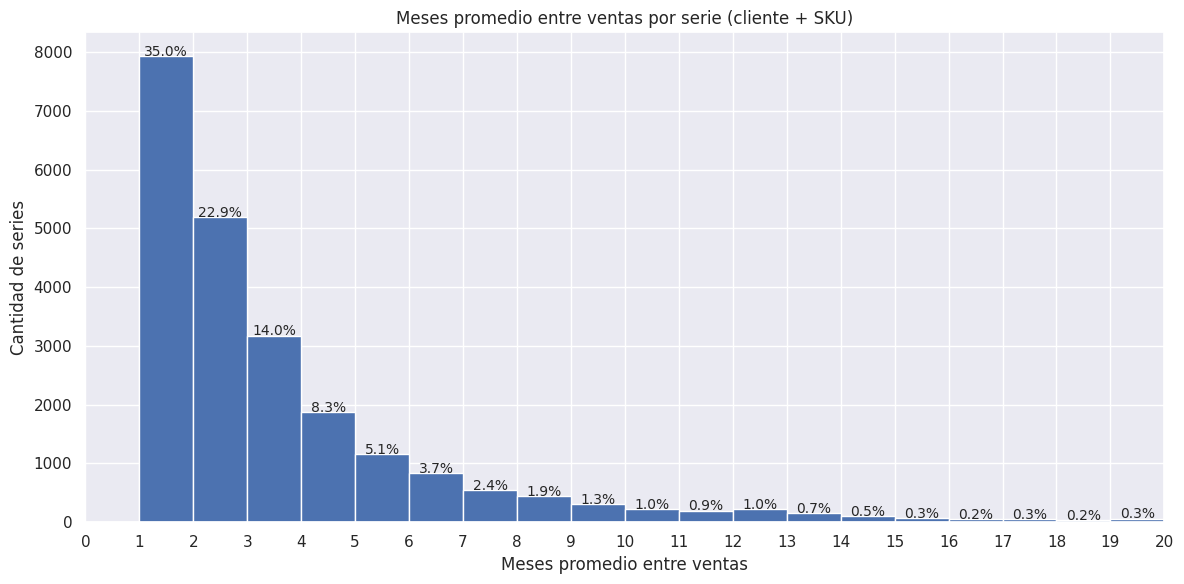

In [34]:
# 1ra opción
agg_df = aggregate_by_pdv_sku(filtered_df, freq='M')
summary_df = series_summary_features(agg_df, col_ventas='cantidad_unidades')

data = summary_df['s_periodo_prom_entre_ventas'].dropna().astype(float)
xticks = np.arange(0, 21, 1)
bins = np.arange(0, 21, 1)

fig, ax = plt.subplots(figsize=(12, 6))
counts, _, _ = ax.hist(data, bins=bins)

# Agregar porcentajes sobre cada barra
total = counts.sum()
for i, count in enumerate(counts):
    if count > 0:
        pct = 100 * count / total
        ax.text(bins[i] + 0.5, count + 1, f"{pct:.1f}%", ha='center', fontsize=10)

ax.set_xlabel('Meses promedio entre ventas')
ax.set_ylabel('Cantidad de series')
ax.set_title('Meses promedio entre ventas por serie (cliente + SKU)')
ax.set_xticks(xticks)
ax.set_xlim((0, 20))
plt.tight_layout()
plt.show()

- Un **72% de las series** tienen un **período de venta promedio menor a 4 meses**. Por lo tanto, podemos considerar  una serie **inactiva a partir de los 4 meses sin ventas**.

**Completitud de las series**

- Series con muchos datos faltantes pueden introducir ruido y dificultar el entrenamiento de los modelos de predicción.

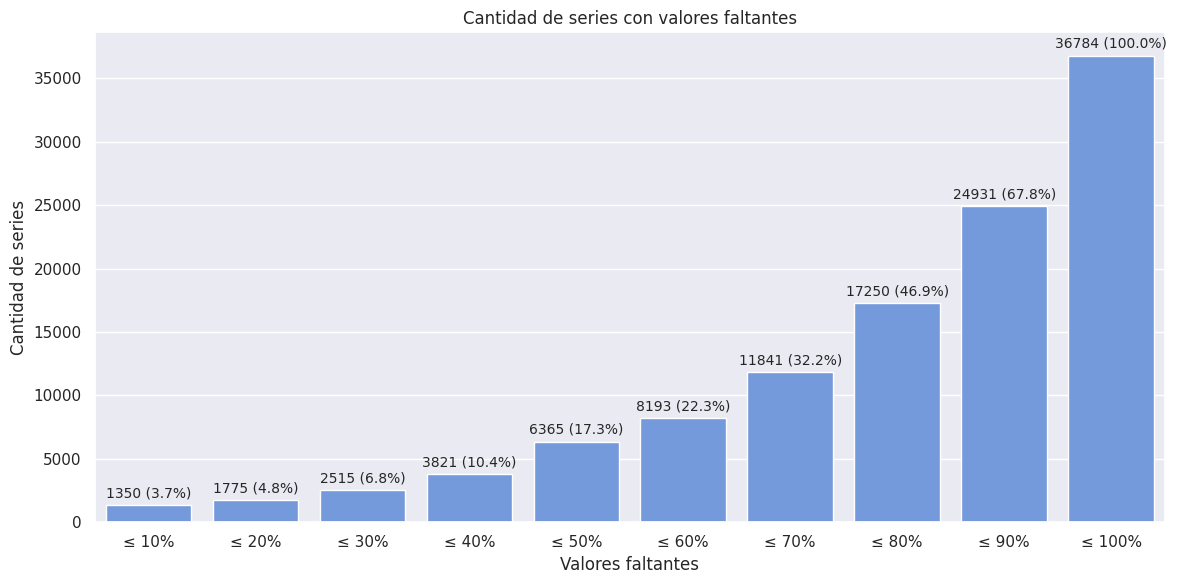

In [35]:
# Crear los bins de incompletitud de 0.1 a 1.0 en pasos de 0.1
bins = np.arange(0.1, 1.1, 0.1)
labels = [f"≤ {int(b * 100)}%" for b in bins]  # Incompletitud máxima permitida

# Calcular la cantidad de series con incompletitud <= cada umbral
counts = [(summary_df['s_completitud'] >= 1 - b).sum() for b in bins]
total_series = summary_df.shape[0]

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x=labels, y=counts, color='cornflowerblue')

# Etiquetas sobre las barras con cantidad y porcentaje
for i, count in enumerate(counts):
    pct = count / total_series * 100
    plt.text(i, count + total_series * 0.01, f'{count} ({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.xlabel('Valores faltantes')
plt.ylabel('Cantidad de series')
plt.title('Cantidad de series con valores faltantes')
plt.tight_layout()
plt.show()


- Las series presentan gran cantidad de valores faltantes, solo el 6.8% (aprox. 2500 series) tiene menos del 30% de valores faltantes.

In [36]:
# Evaluar todos los criterios de filtrado
def evaluate_filtering_ratio(summary_df,  max_periodos_inactivos=4,
                                          min_completitud=0.7,
                                          min_longitud_serie=12):
    """
    Evalúa el impacto del filtrado  de series temporales cliente+SKU
    """
    total_series_original = summary_df.shape[0]
    original_total_qty = summary_df['s_ventas_totales'].sum()

    # Filtrado de series según criterios
    filtered = filter_series(
        summary_df,
        max_periodos_inactivos=max_periodos_inactivos,
        min_completitud=min_completitud,
        min_longitud_serie=min_longitud_serie
    )

    total_series_filtradas = filtered.shape[0]
    porcentaje_series_retenidas = 100 * total_series_filtradas / total_series_original

    total_ventas_filtradas = filtered['s_ventas_totales'].sum()
    porcentaje_cantidad_retenida = 100 * total_ventas_filtradas / original_total_qty

    # Estimar el total de filas imputadas: (longitud esperada - períodos con venta)
    total_periodos_imputados = (filtered['s_longitud_serie'] - filtered['s_cantidad_periodos_con_venta']).sum()
    total_periodos_totales = filtered['s_longitud_serie'].sum()
    porcentaje_imputado = 100 * total_periodos_imputados / total_periodos_totales

    # Clientes y SKUs unicos
    clientes_unicos = filtered['cliente'].nunique()
    skus_unicos = filtered['produc'].nunique()

    resultados = {
        'min_completitud': min_completitud,
        'series_retenidas': total_series_filtradas,
        'series_retenidas(%)': porcentaje_series_retenidas,
        'ventas_retenidas(%)': porcentaje_cantidad_retenida,
        'periodos_a_imputar(%)': porcentaje_imputado,
        'clientes_unicos': clientes_unicos,
        'skus_unicos': skus_unicos
    }
    
    return resultados

In [37]:
agg_df = aggregate_by_pdv_sku(filtered_df, freq='M')
summary_df = series_summary_features(agg_df, col_ventas='cantidad_unidades')

completitud_range = [0, 0.5, 0.6, 0.7, 0.8, 0.9]
resultados = []

for c in completitud_range:
    resultado = evaluate_filtering_ratio(summary_df, min_completitud=c)
    resultados.append(resultado)

resultados_df = pd.DataFrame(resultados).set_index('min_completitud')
resultados_df

,series_retenidas,series_retenidas(%),ventas_retenidas(%),periodos_a_imputar(%),clientes_unicos,skus_unicos
min_completitud,,,,,,
0.0,9397,25.546433,56.309409,58.081827,346,330
0.5,3188,8.666812,36.483377,34.179452,271,270
0.6,1939,5.271314,27.035055,26.830230,228,232
0.7,1090,2.963245,17.535643,20.117403,189,196
0.8,501,1.362005,10.825452,13.387773,120,133
0.9,145,0.394193,4.337399,6.220348,56,66


- Filtramos y **conservamos** únicamente las series con **al menos 12 meses de historial**, tengan **ventas dentro de los últimos 4 meses** y como máximo, un **30% de datos faltantes**. 

- En total, se seleccionaron **1090 series**, que representan el **17.5% del total vendido**, **abarcando 189 clientes y 196 SKUs únicos**.

#### Completado de las series

In [38]:
def add_missing_periods(df, freq='M'):
    """
    Completa las series temporales cliente+SKU con períodos faltantes, y copia
    automáticamente las columnas constantes (con un único valor no nulo por serie).

    Parámetros:
    - df: DataFrame con columnas ['cliente', 'produc', 'period'] y variables numéricas.
    - freq: Frecuencia temporal (por defecto 'M' para mensual).

    Devuelve:
    - DataFrame con períodos completos y NaNs en las columnas no constantes.
    """
    df = df.copy()
    id_cols = ['cliente', 'produc']
    global_max_period = df['period'].max()
    full_dfs = []

    # Detectar columnas constantes por serie (excluyendo id y period)
    other_cols = df.columns.difference(id_cols + ['period'])
    constant_cols = []
    for col in other_cols:
        if df.groupby(id_cols)[col].nunique(dropna=True).le(1).all():
            constant_cols.append(col)

    for (cliente, produc), group in df.groupby(id_cols):
        min_p = group['period'].min()
        full_periods = pd.DataFrame({
            'period': pd.period_range(min_p, global_max_period, freq=freq),
            'cliente': cliente,
            'produc': produc,
        })

        # Copiar valores constantes si existen
        for col in constant_cols:
            val = group[col].dropna().unique()
            if len(val) == 1:
                full_periods[col] = val[0]

        full_dfs.append(full_periods)

    full_index_df = pd.concat(full_dfs, ignore_index=True)

    # Merge con el df original
    df_full = full_index_df.merge(df, on=['cliente', 'produc', 'period'], how='left', suffixes=('', '_drop'))
    df_full = df_full[[col for col in df_full.columns if not col.endswith('_drop')]]

    return df_full

In [39]:
def impute_missing_periods(df, method='ffill', columns=None, window=3):
    """
    Imputa valores faltantes (NaNs) en columnas numéricas de un DataFrame de series temporales
    usando distintos métodos.

    Parámetros:
    - df: DataFrame con columnas ['cliente', 'produc', 'period'] y columnas numéricas con NaNs.
    - method: Método de imputación:
        - 'ffill': forward fill (último valor válido)
        - 'rolling': media móvil (window promedio)
        - 'zero': imputa con cero
    - columns: Lista de columnas a imputar. Si None, se imputan todas excepto id_cols y 'period'.
    - window: ventana para media móvil (solo si method='rolling')

    Devuelve:
    - DataFrame con las columnas imputadas.
    """
    df = df.copy()
    id_cols = ['cliente', 'produc', 'period']
    
    if columns is None:
        columns = df.columns.difference(id_cols)

    # Ordenar por cliente, SKU y periodo
    df = df.sort_values(by=['cliente', 'produc', 'period'])

    # Aplicar imputación por grupo
    for col in columns:
        if method == 'ffill':
            df[col] = df.groupby(['cliente', 'produc'])[col].ffill()
        elif method == 'rolling':
            df[col] = (
                df.groupby(['cliente', 'produc'])[col]
                .apply(lambda x: x.fillna(x.rolling(window=window, min_periods=1).mean()))
                .reset_index(level=[0,1], drop=True)
            )
        elif method == 'zero':
            df[col] = df[col].fillna(0)
        else:
            raise ValueError(f"Método no soportado: {method}")

    return df

Consideraremos dos opciones principales para imputar valores faltantes, que evaluaremos al aplicar los modelos de predicción:

**Opción 1:**  
La **media móvil** considera el promedio de los meses anteriores, por lo que puede imputar valores más representativos que el ffill, que solo replica el último valor observado. Sin embargo, si no hay períodos anteriores cercanos, no puede calcularse y retorna NaN. Por eso, **primero aplicamos media móvil** donde sea posible y **luego completamos los faltantes restantes con ffill**.

**Opción 2:**  
Dado que los períodos con **datos faltantes suelen corresponder a ausencia de ventas y no a la falta de registro**, lo más apropiado es **imputar con 0**. Esto evita generar datos sintéticos (ventas que podrían ser falsas). Sin embargo, imputar con ceros puede introducir ruido en el modelo. En este caso, podrían evaluarse modelos más robustos a series con alta proporción de ceros.

In [40]:
# Armar, filtrar y completar series
agg_df = aggregate_by_pdv_sku(filtered_df, freq='M')
summary_df = series_summary_features(agg_df, col_ventas='cantidad_unidades')

# Merge
agg_df = agg_df.merge(summary_df, on=['cliente', 'produc'], how='left')

agg_df = filter_series(
    agg_df,
    max_periodos_inactivos=4,
    min_completitud=0.7,
    min_longitud_serie=12
)

agg_df = add_missing_periods(agg_df, freq='M')
cols_to_impute = ['cantidad_facturas', 'cantidad_unidades', 'cantidad_productos',
                   'total_facturado', 'unidades_promedio_por_compra', 'productos_promedio_por_compra', 'precio_uni']
print(f"Porcentaje periodos faltantes antes de imputar: {agg_df[cols_to_impute].isnull().mean().mean() * 100:.2f}%")

# Usar rolling mean primero
agg_df = impute_missing_periods(agg_df, method='rolling', 
                                columns=cols_to_impute)

print(f"Porcentaje de valores faltantes después de rolling mean: {agg_df[cols_to_impute].isnull().mean().mean() * 100:.2f}%")

# Luego forward fill para completar los que no se pudieron imputar
agg_df = impute_missing_periods(agg_df, method='ffill', 
                                columns=cols_to_impute)

print(f"Porcentaje de valores faltantes después de forward fill: {agg_df[cols_to_impute].isnull().mean().mean() * 100:.2f}%")

Porcentaje periodos faltantes antes de imputar: 20.12%
Porcentaje de valores faltantes después de rolling mean: 1.41%
Porcentaje de valores faltantes después de forward fill: 0.00%


In [41]:
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28960 entries, 0 to 28959
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype    
---  ------                           --------------  -----    
 0   period                           28960 non-null  period[M]
 1   cliente                          28960 non-null  int64    
 2   produc                           28960 non-null  object   
 3   depo                             28960 non-null  float64  
 4   descripcion                      28960 non-null  object   
 5   s_cantidad_periodos_con_venta    28960 non-null  int64    
 6   s_cantidad_total_facturas        28960 non-null  int64    
 7   s_completitud                    28960 non-null  float64  
 8   s_longitud_serie                 28960 non-null  int64    
 9   s_periodo_prom_entre_ventas      28960 non-null  float64  
 10  s_periodos_desde_ultima_venta    28960 non-null  int64    
 11  s_porcentaje_sobre_total_ventas  28960 non-null  float

### 4. Deflactación de montos

El **objetivo de la deflactación de montos** es eliminar el efecto de la inflación en los valores monetarios para poder analizarlos en términos comparables a lo largo del tiempo.


Utilizamos datos provistos por el **INDEC** desde Enero de 2017 hasta mayo de 2025.

Fuente: https://www.indec.gob.ar/indec/web/Nivel4-Tema-3-5-31

In [42]:
url = "https://raw.githubusercontent.com/Mentoria-M11-g1/practico_1_eda/main/data/sh_ipc_06_25.xls"
ipc = pd.read_excel(url, skiprows=5).dropna()

ipc.head()

,Total nacional,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,...,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00,2025-01-01 00:00:00,2025-02-01 00:00:00,2025-03-01 00:00:00,2025-04-01 00:00:00,2025-05-01 00:00:00
3,Nivel general,1.6,2.1,2.4,2.7,1.4,1.2,1.7,1.4,1.9,...,4.2,3.5,2.7,2.4,2.7,2.2,2.4,3.7,2.8,1.5
4,Alimentos y bebidas no alcohólicas,1.3,1.8,2.8,2.2,1.3,0.9,1.1,2.1,1.8,...,3.6,2.3,1.2,0.9,2.2,1.8,3.2,5.9,2.9,0.5
5,Bebidas alcohólicas y tabaco,0.9,4.3,1.9,2.4,1.7,0.7,3,1.3,0.7,...,3,2.2,3,4,2.5,2.4,1.3,0.8,2.8,0.6
6,Prendas de vestir y calzado,-1,-0.2,3.4,4.5,1.7,0.9,-1.2,-0.6,3.8,...,2.1,6,4.4,1.9,1.6,-0.7,0.4,4.6,3.8,0.9
7,"Vivienda, agua, electricidad, gas y otros comb...",1.5,5.4,3.6,5.9,1.8,1.8,2,2.2,2,...,7,7.3,5.4,4.5,5.3,4,3.7,2.9,1.9,2.4


In [43]:
def extract_ipc_categoria(ipc_df, categoria):
    """
    Extrae el IPC mensual para una categoría específica.

    Parámetros
    ----------
    ipc_df : pd.DataFrame
        DataFrame original del IPC con fechas como columnas y la categoría en la primera columna.
    categoria : str
        Categoría a extraer: "Nivel general", "Alimentos y bebidas no alcohólicas", etc.

    Retorna
    -------
    pd.DataFrame con columnas: ['fecha', 'ipc_var_mensual']
    """
    ipc_df = ipc_df.copy()

    # Asegurar que la primera columna se llama 'categoria'
    ipc_df.rename(columns={ipc_df.columns[0]: 'categoria'}, inplace=True)

    # Filtrar la fila con la categoría deseada
    fila = ipc_df[ipc_df['categoria'] == categoria]

    # Quitar la columna 'categoria' y transponer
    valores = fila.drop(columns='categoria').iloc[0]

    # Convertir en DataFrame
    df_limpio = valores.reset_index()
    df_limpio.columns = ['fecha', 'ipc_var_mensual']
    df_limpio['fecha'] = pd.to_datetime(df_limpio['fecha'])

    return df_limpio

In [44]:
ipc_alimentos = extract_ipc_categoria(ipc, "Alimentos y bebidas no alcohólicas")
ipc_alimentos = ipc_alimentos.sort_values('fecha').reset_index(drop=True)

ipc_alimentos.head(10)

,fecha,ipc_var_mensual
0,2017-01-01,1.3
1,2017-02-01,1.8
2,2017-03-01,2.8
3,2017-04-01,2.2
4,2017-05-01,1.3
5,2017-06-01,0.9
6,2017-07-01,1.1
7,2017-08-01,2.1
8,2017-09-01,1.8
9,2017-10-01,1.5


#### Metodo de deflactacion

1. Calcular el **factor multiplicativo mensual**:

$$
\text{factor}_t = 1 + \frac{ipcVarMensual_t}{100}
$$

- Si en un mes el IPC varía un +3%, entonces: $\text{factor}_t = 1.03$

2. Calcular el **indice acumulado**:

$$
indice_t = \prod_{i=1}^{t} factor_i
$$


3. **Normalizar respecto al periodo base**:

$$
indiceNorm_t = \frac{indice_t}{indice_{base}}
$$


4. Aplicar la **deflactacion** al valor monetario:

$$
x^{deflactado}_t = \frac{x_t}{indiceNorm_t}
$$

In [45]:
def deflactar_por_ipc( df, 
    ipc_df, 
    value_col,
    ipc_col='ipc_var_mensual', 
    base_period=None
):
    """
    Deflacta una columna monetaria ajustando por IPC mensual.

    Parámetros:
    - df: DataFrame original con fechas y columna monetaria.
    - ipc_df: DataFrame con columnas ['fecha', 'ipc_var_mensual'].
    - value_col: Nombre de la columna monetaria a deflactar.
    - ipc_col: Columna de IPC mensual (%).
    - base_period: Periodo base para deflactar (formato 'YYYY-MM'). Si None, se usa el último disponible.

    Devuelve:
    - df con una nueva columna: '{value_col}_deflactado'
    """
    df = df.copy()
    ipc_df = ipc_df.copy()

    # Convertir fechas a periodo mensual
    ipc_df['period'] = pd.to_datetime(ipc_df['fecha']).dt.to_period('M')
    # Asegurar que las columnas son numéricas
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    ipc_df[ipc_col] = pd.to_numeric(ipc_df[ipc_col], errors='coerce')

    # Ordenar IPC y calcular índice acumulado
    ipc_df = ipc_df.sort_values('period').copy()
    ipc_df['ipc_factor'] = 1 + (ipc_df[ipc_col] / 100)
    ipc_df['ipc_index'] = ipc_df['ipc_factor'].cumprod()

    # Determinar el índice base
    if base_period is None:
        base_index = ipc_df['ipc_index'].iloc[-1]
    else:
        base_period = pd.Period(base_period, freq='M')
        if base_period not in ipc_df['period'].values:
            raise ValueError(f"El periodo base '{base_period}' no se encuentra en el DataFrame de IPC.")
        base_index = ipc_df.loc[ipc_df['period'] == base_period, 'ipc_index'].values[0]

    # Normalizar el índice
    ipc_df['ipc_index_norm'] = ipc_df['ipc_index'] / base_index

    # Merge por periodo
    df = df.merge(ipc_df[['period', 'ipc_index_norm']], on='period', how='left')

    # Deflactar la columna de precios
    col_deflactado = f'{value_col}_deflactado'
    df[col_deflactado] = df[value_col] / df['ipc_index_norm']

    return df.drop(columns=['ipc_index_norm'])

In [46]:
## Periodo base igual al último mes del DataFrame
base_period = agg_df['period'].max().strftime('%Y-%m')
agg_df['fecha'] = agg_df['period'].dt.to_timestamp()    # agregar al agg_df

# Deflactar las columnas monetarias
monetary_cols = [
    'precio_uni', 
    'total_facturado'
]

for col in monetary_cols:
    agg_df = deflactar_por_ipc(
        df=agg_df,
        ipc_df=ipc_alimentos,
        value_col=col,
        base_period=base_period
    )

agg_df[['period','precio_uni', 'precio_uni_deflactado', 'total_facturado', 'total_facturado_deflactado']].sort_values(by='period', ascending=True)

,period,precio_uni,precio_uni_deflactado,total_facturado,total_facturado_deflactado
18506,2022-01,37.3851,415.451861,226.18,2513.485371
15680,2022-01,34.9285,388.152241,152.15,1690.807318
13502,2022-01,64.4429,716.138856,210.55,2339.792842
23001,2022-01,98.6645,1096.435482,214.90,2388.133373
20005,2022-01,293.4900,3261.485638,355.12,3946.365395
...,...,...,...,...,...
24533,2024-06,5306.1712,5306.171200,6420.46,6420.460000
24555,2024-06,399.6122,399.612200,1208.83,1208.830000
24569,2024-06,539.4987,539.498700,3916.75,3916.750000
24484,2024-06,317.3018,317.301800,1345.00,1345.000000


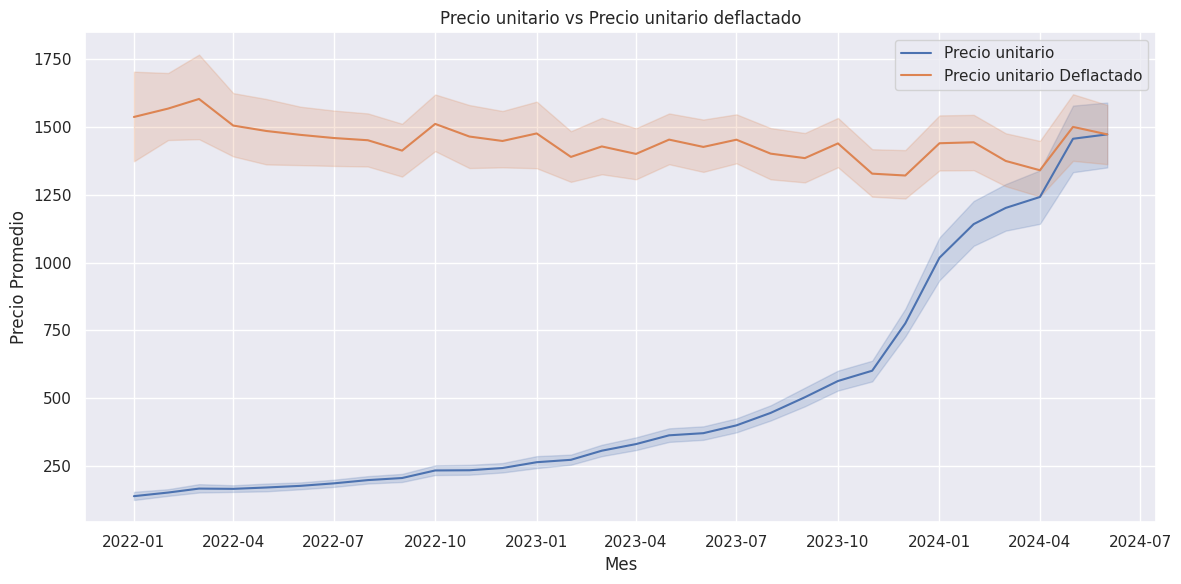

In [47]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=agg_df, x='fecha', y='precio_uni', label='Precio unitario')
sns.lineplot(data=agg_df, x='fecha', y='precio_uni_deflactado', label='Precio unitario Deflactado')
plt.title('Precio unitario vs Precio unitario deflactado')
plt.xlabel('Mes')
plt.ylabel('Precio Promedio')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

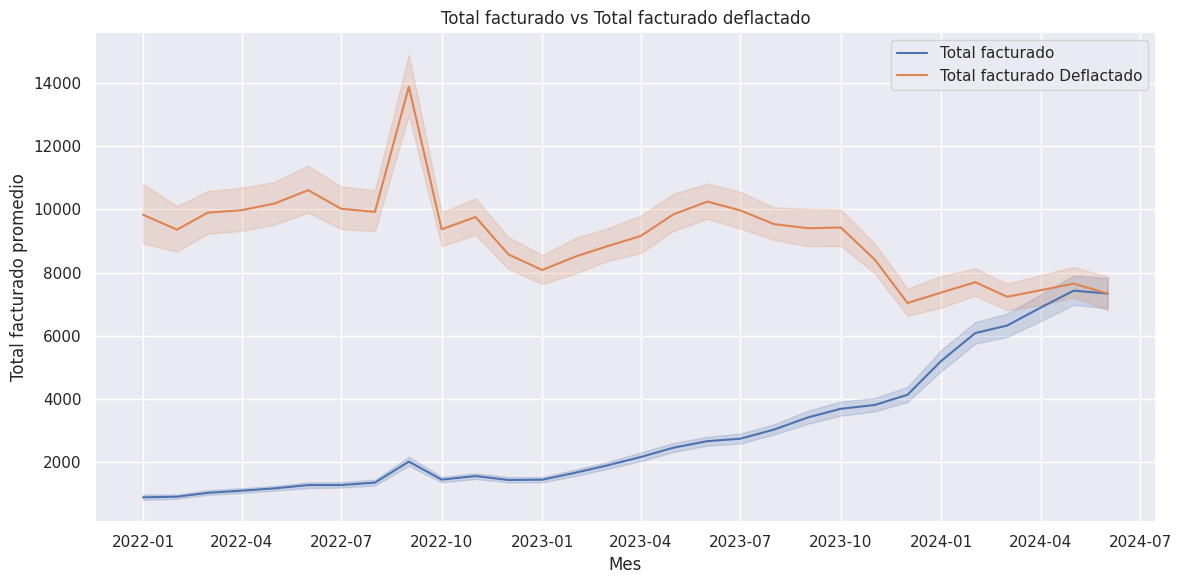

In [48]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=agg_df, x='fecha', y='total_facturado', label='Total facturado')
sns.lineplot(data=agg_df, x='fecha', y='total_facturado_deflactado', label='Total facturado Deflactado')
plt.title('Total facturado vs Total facturado deflactado')
plt.xlabel('Mes')
plt.ylabel('Total facturado promedio')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Transformación de variables

Como se observó en el EDA, las series muestran cierta estacionalidad según el mes del año, por lo que incorporar variables como mes, trimeste y año puede ser útil para mejorar la predicción.

In [49]:
def add_time_features(df, period_col='period'):
    """
    Agrega características temporales al DataFrame basado en una columna de fecha.
    
    Devuelve:
    - DataFrame con nuevas columnas de características temporales.
    """
    df = df.copy()
    # Estandarizar la columna de fecha
    df['fecha'] = pd.to_datetime(df[period_col].dt.to_timestamp(), errors='coerce')
    
    # Extraer características
    df['mes'] = df['fecha'].dt.month
    df['año'] = df['fecha'].dt.year
    df['trimestre'] = df['fecha'].dt.quarter
    
    return df

In [50]:
agg_df = add_time_features(agg_df, period_col='period')
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28960 entries, 0 to 28959
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   period                           28960 non-null  period[M]     
 1   cliente                          28960 non-null  int64         
 2   produc                           28960 non-null  object        
 3   depo                             28960 non-null  float64       
 4   descripcion                      28960 non-null  object        
 5   s_cantidad_periodos_con_venta    28960 non-null  int64         
 6   s_cantidad_total_facturas        28960 non-null  int64         
 7   s_completitud                    28960 non-null  float64       
 8   s_longitud_serie                 28960 non-null  int64         
 9   s_periodo_prom_entre_ventas      28960 non-null  float64       
 10  s_periodos_desde_ultima_venta    28960 non-null  int64    

**Categorizacion de productos**

Agrupar los productos por **categoría** puede ser útil para analizar el comportamiento de ventas a nivel de categoría.

En caso de utilizarse en algoritmos de machine learning, es necesario aplicar algún tipo de codificación (encoding), como por ejemplo: One-Hot Encoding, Label Encoding, Target Encoding.

In [51]:
def assign_product_type(df, descrip_col='descrip_estand', new_col='tipo_producto', category_keywords_dict=None):
    """
    Asigna un tipo de producto a partir de la descripción, usando un diccionario {categoria: [keywords]}.

    Parámetros:
    - df: DataFrame de entrada.
    - descrip_col: Columna con la descripción del producto.
    - new_col: Columna a crear con el tipo de producto.
    - category_keywords_dict: Diccionario {categoria: [keywords]}.

    Retorna:
    - DataFrame con nueva columna 'tipo_producto' asignada.
    """
    df = df.copy()
    df[new_col] = 'otro'  # valor por defecto

    if category_keywords_dict is None:
        return df

    for category, keywords in category_keywords_dict.items():
        for keyword in keywords:
            mask = df[descrip_col].str.contains(keyword, case=False, na=False)
            df.loc[mask, new_col] = category

    return df

In [52]:
category = {
    'alfajor': ['alf', 'triple', 'tatin'],
    'bombones-bocaditos': [
        'seleccion arcor',
        'bombones',
        'bon o bon leche',
        'bon o bon blanco',
        'bon o bon surt',
        'bon o bon aguila',
        'tofi',
        'cabsha',
        'dulcilac',
        ],
    'chocolate': [
        'cofler aireado', 
        'cofler block 38 grs',
        'baño rep aguila semi',
        'aguila 100g',
        'celofan',
        'barrita aguila', 
        'tab milk',
        'tableta arcor milk',
        'choc arcor marmolado',
        'aguila extrafino',
        'chocolatin',
        'cofler block x 110 grs',
        'aguila taza leche x 100 grs',
        'cofler block x 170 grs',
        'cofler block miti miti x 170 grs',
        'mani con chocolate arcor',
        'cofler macizo leche x 55 grs',
        ],
    'caramelos': [
        'mogul',
        'butter toffees',
        'masticable',
        'mog',
        'gajitos',
        'choco mani',
        'chocomani',
        'choco - mani',
        'tubitos',
        'rellenos miel',
        'menta cristal',
        'fresh cristal',
        'menta chocolate',
        'saquito fruta',
        'saq frutal',
        'rell miel',
        'relleno miel mta',
        'lotza fizz',
        'rodajas acidas',
        'baston viena x 470 grs',
        'poosh frutis',
        'mix cristales',
        'cremino surtido',
    ],
    'saladix': ['saladix'],
    'mentho plus': ['plus', 'mentho'],
    'topline': ['topline', 'tab t', 'tp 7'],
    'turron': ['turron'],
    'salsa': ['salsa'],
    'rocklets': ['rockleton','rocklet'],
    'galletitas surtidas': ['diversion', 'bagley'],
    'barrita de cereal': ['cereal mix'],
    'galletitas saladas': [
        'hogareñas', 
        'traviata', 
        'serranas',
        'criollitas',
        'serranitas',
        ],
    'jugo en polvo': ['jg pv'],
    'mermelada': ['merm', 'mer'],
    'oblea': ['opera', 'oblea'],
    'galletitas dulces': [
        'mana',
        'formis',
        'chocolinas',
        'macucas',
        'sonrisas',
        'rumba',
        'amor',
        'melitas',
        'porteitas',
        'vainitas',
        'tortitas chocolate',
        'tortitas black',
        'porteñitas',
        'coquitas',
        'mellizas',
        'gall. cereal mix',
    ],
    'snack': ['rex', 'kesitas', 'snack'],
    'almacen': [
        'tomate',
        'atun',
        'pasta',
        'presto',
        'pure arcor',
        'arvejas',
        'lentejas',
        'garbanzos',
        'azucar comun',
        'choclo', 
        'aceite',
        'mayo',
        'jardinera',
        'mayonesa',
    ],
    'chupetin': ['pops'],
    'chicle': ['flics'],
    'reposteria': ['bizcoch'],
    'obleas': ['graffiti'],
    'dulce': ['batata', 'membrillo'],
    'bebida': ['beb'],
    'helado': ['gelato'],
    'tostadas': ['tost crio'],
    'huevo pascua': ['h milk c sorpresa', 'huevo milk'],
    'barrita cereal': [
        'barra nat b',
    ],
    'especias': ['esp provenzal', 'esp pimenton','esp oregano', 'esp cond', 'esp aji molido']
}

In [53]:
agg_df = assign_product_type(
    df=agg_df,
    descrip_col='descripcion',
    new_col='tipo_producto',
    category_keywords_dict=category
)

agg_df['tipo_producto'].value_counts().sort_values(ascending=False)

tipo_producto
alfajor                4739
caramelos              4160
galletitas dulces      2840
chocolate              2329
galletitas saladas     2249
oblea                  2158
snack                  1853
mentho plus            1534
saladix                1208
topline                1122
bombones-bocaditos      693
barrita de cereal       652
turron                  624
rocklets                561
mermelada               521
salsa                   385
galletitas surtidas     383
chupetin                285
almacen                 221
jugo en polvo           202
barrita cereal           75
obleas                   74
especias                 48
dulce                    44
Name: count, dtype: int64

In [54]:
otro_df = agg_df[agg_df['tipo_producto'] == 'otro']
print(f'total de registros con tipo_producto "otro": {len(otro_df)}')

# Descripciones mas repetidas
otro_df['descripcion'].value_counts().sort_values(ascending=False).head(30)

total de registros con tipo_producto "otro": 0


Series([], Name: count, dtype: int64)

### 6. Estandarización o normalización

Aplicamos estandarización o normalización para asegurar que todas las variables contribuyan equitativamente en algoritmos de machine learning basados en distancias, como K-Means o DBSCAN.

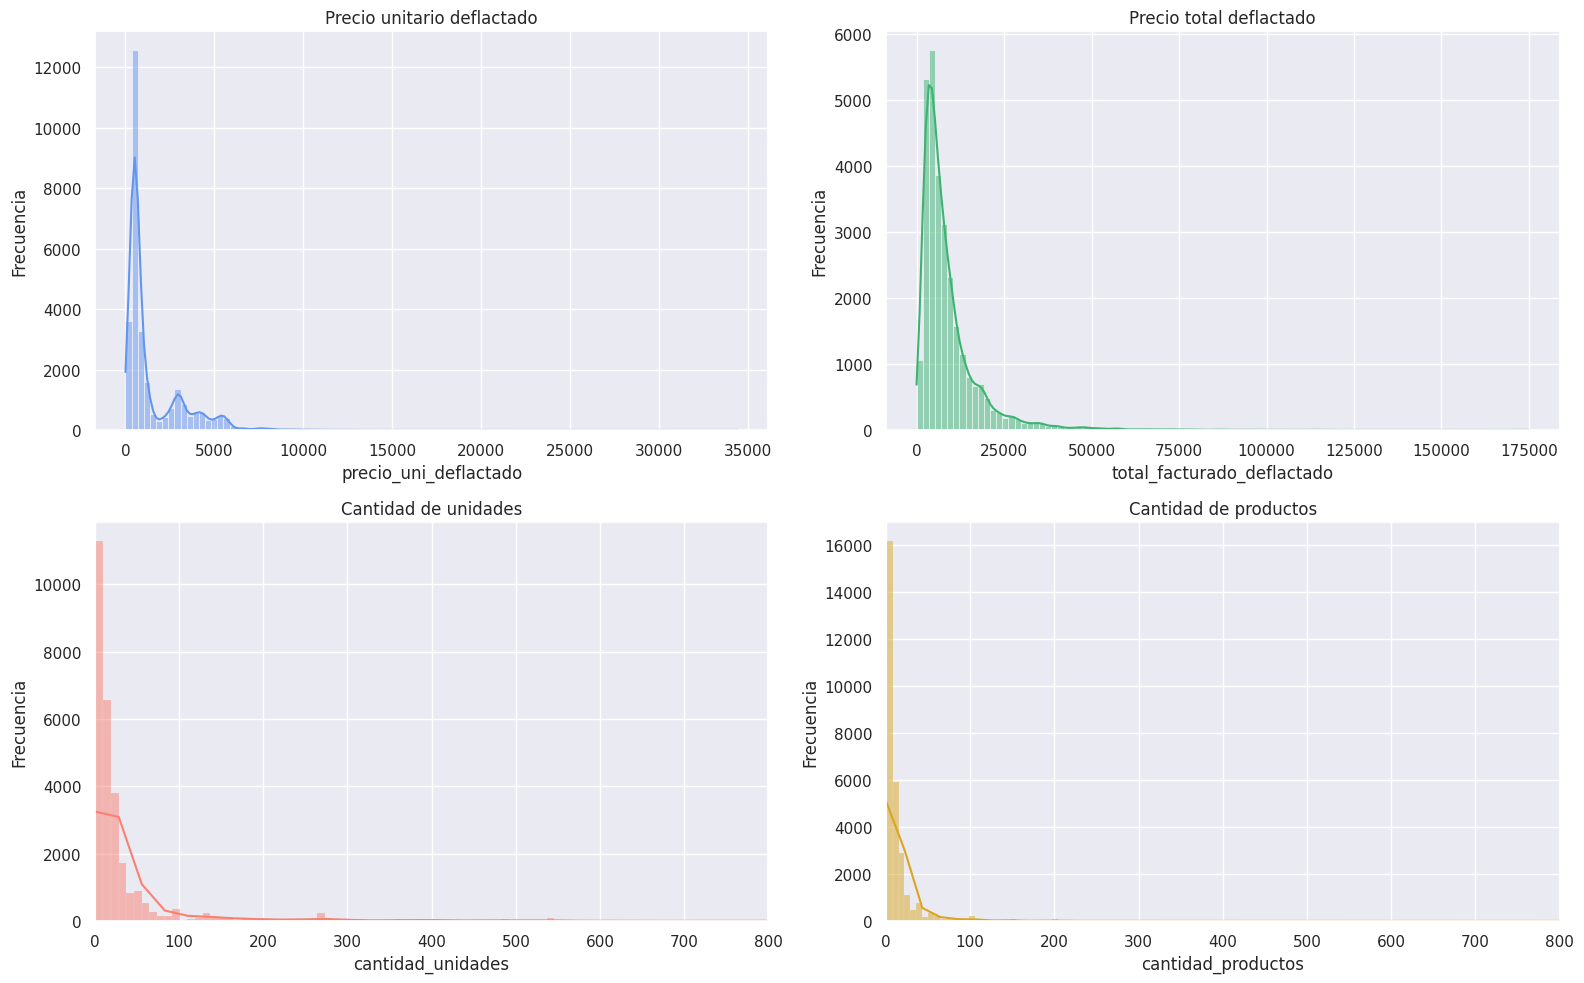

In [55]:
# Distribuciones de las variables monetarias y cantidades
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Precio unitario deflactado 
sns.histplot(agg_df['precio_uni_deflactado'], kde=True, ax=axes[0, 0], color='cornflowerblue', bins=100)
axes[0, 0].set_title('Precio unitario deflactado')
axes[0, 0].set_xlabel('precio_uni_deflactado')
axes[0, 0].set_ylabel('Frecuencia')

# Precio total deflactado
sns.histplot(agg_df['total_facturado_deflactado'], kde=True, ax=axes[0, 1], color='mediumseagreen', bins=100)
axes[0, 1].set_title('Precio total deflactado')
axes[0, 1].set_xlabel('total_facturado_deflactado')
axes[0, 1].set_ylabel('Frecuencia')

# Cantidad de unidades
sns.histplot(agg_df['cantidad_unidades'], kde=True, ax=axes[1, 0], color='salmon', bins=600)
axes[1, 0].set_title('Cantidad de unidades')
axes[1, 0].set_xlabel('cantidad_unidades')
axes[1, 0].set_xlim(0, 800)
axes[1, 0].set_ylabel('Frecuencia')

# Cantidad de productos
sns.histplot(agg_df['cantidad_productos'], kde=True, ax=axes[1, 1], color='goldenrod', bins=600)
axes[1, 1].set_title('Cantidad de productos')
axes[1, 1].set_xlabel('cantidad_productos')
axes[1, 1].set_xlim(0, 800)
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Las **distribuciones** de las cantidades vendidas y precios presentan **alta asimetría** y colas largas hacia **valores extremos**.

Si bien tanto StandardScaler como MinMaxScaler son sensibles a outliers, MinMaxScaler lo es aún más, ya que depende directamente de los valores mínimos y máximos.

Por este motivo, se utilizará **StandardScaler**. En caso de que no funcione adecuadamente, se podría considerarar el uso de **RobustScaler**, que es más adecuado para distribuciones asimétricas con valores atípicos. Otra alternativa es aplicar una transformación logarítmica previa para reducir el efecto de los outliers y luego escalar.

In [56]:
cols_to_scale = ['cantidad_unidades', 'cantidad_productos', 'precio_uni_deflactado', 'total_facturado_deflactado']
scaler = StandardScaler()
scaled = scaler.fit_transform(agg_df[cols_to_scale])

# Agregar columnas escaladas al DataFrame
for i, col in enumerate(cols_to_scale):
    agg_df[f'{col}_escalada'] = scaled[:, i]

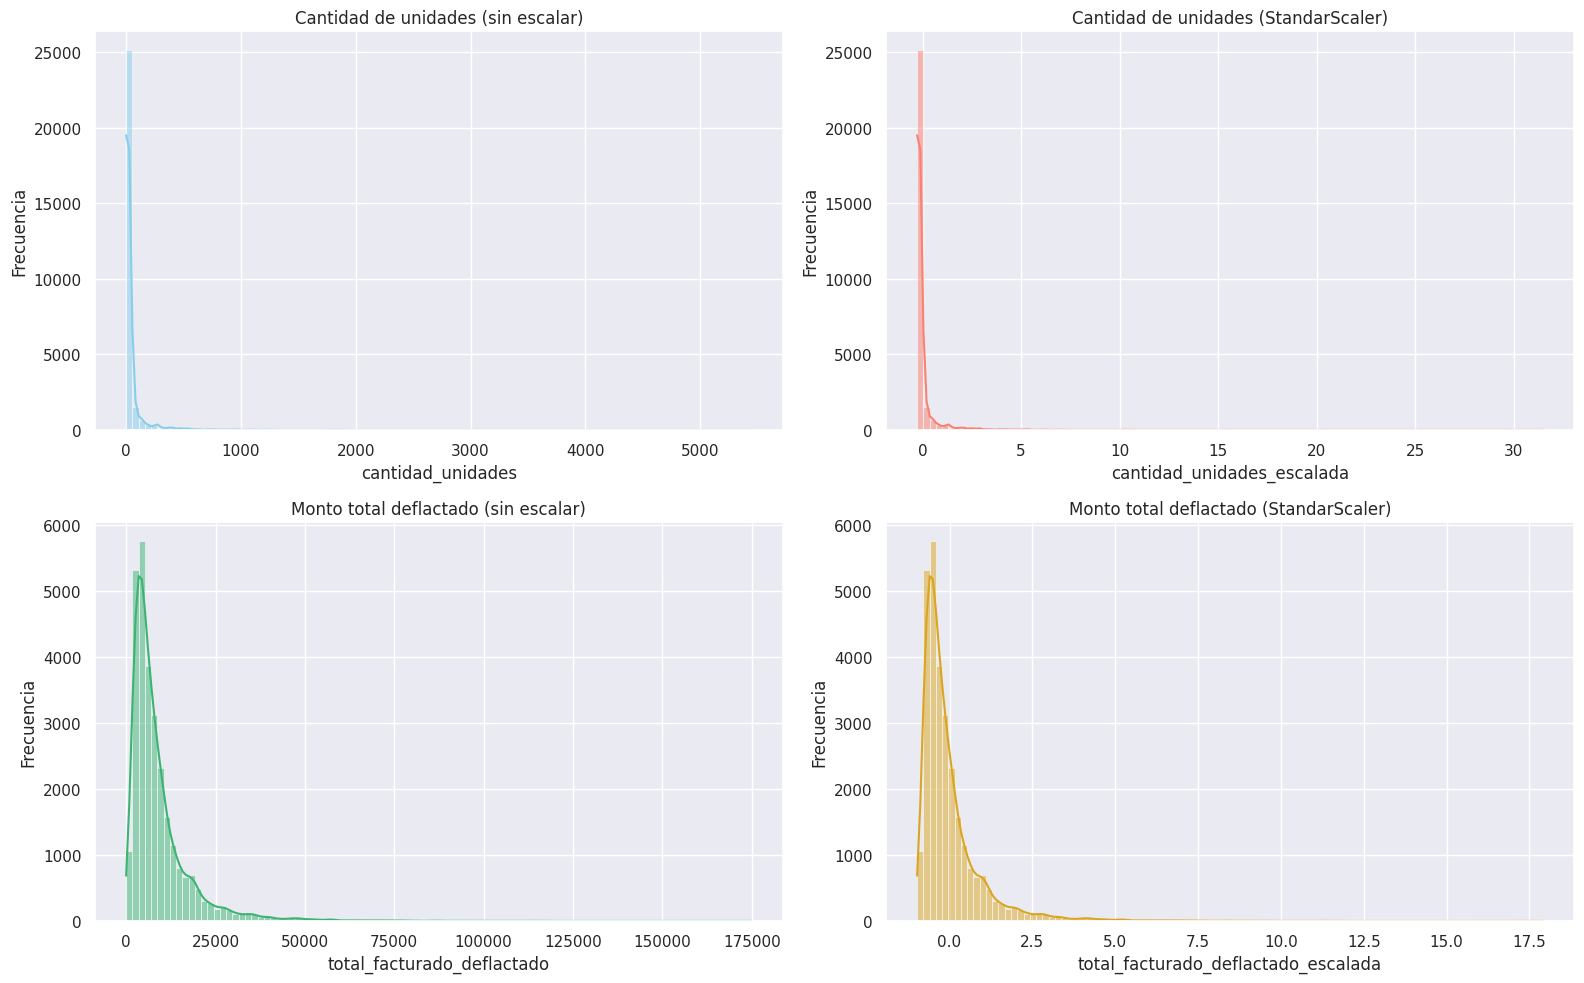

In [57]:
# Graficar las distribuciones de las variables monetarias y cantidades antes y después de escalar
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cantidad de unidades
sns.histplot(agg_df['cantidad_unidades'], kde=True, ax=axes[0, 0], color='skyblue', bins=100)
axes[0, 0].set_title('Cantidad de unidades (sin escalar)')
axes[0, 0].set_xlabel('cantidad_unidades')
axes[0, 0].set_ylabel('Frecuencia')

sns.histplot(agg_df['cantidad_unidades_escalada'], kde=True, ax=axes[0, 1], color='salmon', bins=100)
axes[0, 1].set_title('Cantidad de unidades (StandarScaler)')
axes[0, 1].set_xlabel('cantidad_unidades_escalada')
axes[0, 1].set_ylabel('Frecuencia')

# Monto total deflactado
sns.histplot(agg_df['total_facturado_deflactado'], kde=True, ax=axes[1, 0], color='mediumseagreen', bins=100)
axes[1, 0].set_title('Monto total deflactado (sin escalar)')
axes[1, 0].set_xlabel('total_facturado_deflactado')
axes[1, 0].set_ylabel('Frecuencia')

sns.histplot(agg_df['total_facturado_deflactado_escalada'], kde=True, ax=axes[1, 1], color='goldenrod', bins=100)
axes[1, 1].set_title('Monto total deflactado (StandarScaler)')
axes[1, 1].set_xlabel('total_facturado_deflactado_escalada')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 7. Verificación de consistencia

Verificar que:
- No existan claves primarias duplicadas.  

- No queden valores nulos.  

- Comprobar que los tipos de las columnas de las claves primarias sean correctos.  

- Las series tengan frecuencia mensual y esten completas, sin valores faltantes.  

In [58]:
def verificar_consistencia_primarias(df, col_pdv='PDV', col_sku='SKU', col_fecha='fecha'):
    """
    Verifica paso a paso la consistencia de claves primarias (PDV, SKU, fecha)
    y la completitud mensual de las series.
    """
    print("\n🔍 Verificación de consistencia de claves primarias...\n")

    # Paso 1: Verificar existencia de columnas clave
    print("Paso 1: Verificación de columnas clave...")
    columnas_faltantes = [col for col in [col_pdv, col_sku, col_fecha] if col not in df.columns]
    if columnas_faltantes:
        print(f" ❌ FALTAN columnas requeridas: {columnas_faltantes}")
        return
    else:
        print(" ✅ Todas las columnas clave están presentes.")

    # Paso 2: Verificar nulos
    print("\nPaso 2: Verificación de valores nulos...")
    columnas_con_nulos = df.columns[df.isnull().any()].tolist()
    if columnas_con_nulos:
        print(f" ⚠️ Se encontraron nulos en las columnas: {columnas_con_nulos}")
    else:
        print(" ✅ No se encontraron valores nulos.")

    # Paso 3: Verificación de duplicados en clave primaria
    print("\nPaso 3: Verificación de duplicados en la clave primaria (PDV, SKU, fecha)...")
    duplicados = df.duplicated(subset=[col_pdv, col_sku, col_fecha]).sum()
    if duplicados > 0:
        print(f" ❌ Se encontraron {duplicados} filas duplicadas en la clave primaria.")
    else:
        print(" ✅ No hay duplicados en la clave primaria.")

    # Paso 4: Verificación de tipos de datos
    print("\nPaso 4: Verificación de tipos de datos en columnas clave...")
    tipos_ok = (
        pd.api.types.is_integer_dtype(df[col_pdv]) and
        pd.api.types.is_object_dtype(df[col_sku]) and
        pd.api.types.is_datetime64_any_dtype(df[col_fecha])
    )
    if not tipos_ok:
        print(" ❌ Los tipos no coinciden con los esperados: PDV=int64, SKU=object, fecha=datetime64[ns]")
        print(f"    Tipos encontrados: {df[[col_pdv, col_sku, col_fecha]].dtypes.to_dict()}")
    else:
        print(" ✅ Los tipos de datos son correctos.")

    # Paso 5: Verificación de completitud mensual de las series
    print("\nPaso 5: Verificación de que las series sean mensuales completas (sin huecos)...")
    df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')
    grupos = df.groupby([col_pdv, col_sku])
    total_series = len(grupos)
    series_mensuales_completas = []
    series_con_huecos = []

    for (pdv, sku), grupo in grupos:
        fechas = pd.Series(sorted(grupo[col_fecha].dropna().unique()))
        if len(fechas) < 2:
            continue 

        inicio = fechas.min()
        fin = fechas.max()
        fechas_esperadas = pd.date_range(start=inicio, end=fin, freq='MS')  # frecuencia mensual

        if set(fechas_esperadas) == set(fechas):
            series_mensuales_completas.append((pdv, sku))
        else:
            series_con_huecos.append((pdv, sku))

    if len(series_con_huecos) > 0:
        print(f" ⚠️ {len(series_con_huecos)} de {total_series} series tienen fechas faltantes en el rango mensual.")
    else:
        print(" ✅ Todas las series están completas y tienen frecuencia mensual.")

    # Paso 6: Resumen final
    print("\n📋 Resumen final:")
    print(f" - Series totales: {total_series}")
    print(f" - Series completas y mensuales: {len(series_mensuales_completas)}")
    print(f" - Series con fechas faltantes o no mensuales: {len(series_con_huecos)}")

    print("\n✅ Verificación completada.\n")

In [59]:
verificar_consistencia_primarias(agg_df, col_pdv='cliente', col_sku='produc', col_fecha='fecha')


🔍 Verificación de consistencia de claves primarias...

Paso 1: Verificación de columnas clave...
 ✅ Todas las columnas clave están presentes.

Paso 2: Verificación de valores nulos...
 ✅ No se encontraron valores nulos.

Paso 3: Verificación de duplicados en la clave primaria (PDV, SKU, fecha)...
 ✅ No hay duplicados en la clave primaria.

Paso 4: Verificación de tipos de datos en columnas clave...
 ✅ Los tipos de datos son correctos.

Paso 5: Verificación de que las series sean mensuales completas (sin huecos)...
 ✅ Todas las series están completas y tienen frecuencia mensual.

📋 Resumen final:
 - Series totales: 1090
 - Series completas y mensuales: 1090
 - Series con fechas faltantes o no mensuales: 0

✅ Verificación completada.



**Guardar dataset**

In [60]:
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28960 entries, 0 to 28959
Data columns (total 33 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   period                               28960 non-null  period[M]     
 1   cliente                              28960 non-null  int64         
 2   produc                               28960 non-null  object        
 3   depo                                 28960 non-null  float64       
 4   descripcion                          28960 non-null  object        
 5   s_cantidad_periodos_con_venta        28960 non-null  int64         
 6   s_cantidad_total_facturas            28960 non-null  int64         
 7   s_completitud                        28960 non-null  float64       
 8   s_longitud_serie                     28960 non-null  int64         
 9   s_periodo_prom_entre_ventas          28960 non-null  float64       
 10  s_periodos

In [ ]:
path = 'data/df_agregado.csv'
agg_df.to_csv(path, index=False)
print(f"DataFrame agregado guardado en: {path}")

DataFrame agregado guardado en: data/df_agregado.csv


**💡 Observaciones para el modelado**

- Aunque se conservaron todas las columnas, para el modelado es fundamental seleccionar las variables relevantes y evitar redundancias, por ejemplo entre precio unitario y su versión deflactada.

- Si se utilizan variables categóricas como tipo_producto, es necesario aplicar algún tipo de encoding.

- Es posible generar embeddings a partir de las descripciones de producto para que puedan ser utilizadas como variables en los modelos.